# Используем PyTorch

# БЛОК 1: ИМПОРТЫ И НАСТРОЙКИ

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import joblib

# Проверка доступности GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


# БЛОК 2: ЗАГРУЗКА И ПРЕДОБРАБОТКА ДАННЫХ

In [2]:
# Загрузка данных
df = pd.read_csv('medical_features_analysis.csv')

# Просмотр структуры данных
print("Размерность данных:", df.shape)
print("\nДиагнозы:", df['diagnosis_code'].value_counts())

# Предобработка данных
df.fillna(0, inplace=True)

# Выбор признаков
exclude_columns = ['filename', 'diagnosis_code', 'diagnosis_name']
feature_columns = [col for col in df.columns if col not in exclude_columns]

X = df[feature_columns].values
y = df['diagnosis_code'].values

# Кодирование меток
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(np.unique(y_encoded))

print(f"Количество классов: {num_classes}")
print(f"Размерность признаков: {X.shape}")

# Нормализация данных
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Размерность данных: (1569, 45)

Диагнозы: diagnosis_code
C34-C35    350
J44-J45    324
A15-A16    221
J45-J46    214
D14-D15    185
U07-U8     180
J15-J16     95
Name: count, dtype: int64
Количество классов: 7
Размерность признаков: (1569, 42)


# БЛОК 3: РАЗДЕЛЕНИЕ ДАННЫХ И СОЗДАНИЕ DATALOADER

In [11]:
# Разделение на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Преобразование в тензоры PyTorch
X_train_tensor = torch.FloatTensor(X_train).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)

# Создание DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Размерность тренировочных данных: {X_train_tensor.shape}")
print(f"Размерность тестовых данных: {X_test_tensor.shape}")

Размерность тренировочных данных: torch.Size([1255, 42])
Размерность тестовых данных: torch.Size([314, 42])


# БЛОК 4: ОПРЕДЕЛЕНИЕ АРХИТЕКТУРЫ МОДЕЛИ

In [12]:

class SimpleMedicalTransformer(nn.Module):
    def __init__(self, input_dim, num_classes, hidden_dim=256, num_heads=8, dropout=0.1):
        super(SimpleMedicalTransformer, self).__init__()
        
        self.hidden_dim = hidden_dim
        
        # Проекция входных данных
        self.input_projection = nn.Linear(input_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        
        # Multi-Head Self-Attention
        self.self_attention = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.layer_norm1 = nn.LayerNorm(hidden_dim)
        
        # Feed Forward Network
        self.ffn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.Dropout(dropout)
        )
        self.layer_norm2 = nn.LayerNorm(hidden_dim)
        
        # Классификационная головка
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )
        
    def forward(self, x):
        # Сохраняем оригинальную форму
        batch_size = x.size(0)
        
        # Проекция и нормализация
        x_proj = self.input_projection(x)  # (batch_size, hidden_dim)
        x_proj = self.bn1(x_proj)
        
        # Добавляем sequence dimension для attention
        x_seq = x_proj.unsqueeze(1)  # (batch_size, 1, hidden_dim)
        
        # Self-Attention с residual connection
        attn_output, _ = self.self_attention(x_seq, x_seq, x_seq)
        x_attn = self.layer_norm1(x_seq + attn_output)
        
        # Feed Forward с residual connection
        ff_output = self.ffn(x_attn)
        x_out = self.layer_norm2(x_attn + ff_output)
        
        # Усредняем по последовательности
        x_pooled = x_out.mean(dim=1)  # (batch_size, hidden_dim)
        
        # Классификация
        output = self.classifier(x_pooled)
        
        return output

# БЛОК 5: ИНИЦИАЛИЗАЦИЯ МОДЕЛИ И ОПТИМИЗАТОРА

In [13]:
# Создание модели
input_dim = X_train.shape[1]
model = SimpleMedicalTransformer(
    input_dim=input_dim,
    num_classes=num_classes,
    hidden_dim=256,
    num_heads=8,
    dropout=0.1
).to(device)

print("Трансформер модель создана успешно")
print(f"Количество параметров: {sum(p.numel() for p in model.parameters()):,}")

# Функция потерь и оптимизатор
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# Scheduler для learning rate
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10
)

Трансформер модель создана успешно
Количество параметров: 580,615


# БЛОК 6: ФУНКЦИИ ДЛЯ ОБУЧЕНИЯ И ВАЛИДАЦИИ

In [14]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    
    for batch_X, batch_y in tqdm(dataloader, desc="Обучение"):
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * batch_X.size(0)
        _, predicted = torch.max(outputs, 1)
        correct_predictions += (predicted == batch_y).sum().item()
        total_samples += batch_X.size(0)
    
    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples
    
    return epoch_loss, epoch_accuracy

def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    all_predictions = []
    all_targets = []
    
    with torch.no_grad():
        for batch_X, batch_y in tqdm(dataloader, desc="Валидация"):
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            
            running_loss += loss.item() * batch_X.size(0)
            _, predicted = torch.max(outputs, 1)
            correct_predictions += (predicted == batch_y).sum().item()
            total_samples += batch_X.size(0)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(batch_y.cpu().numpy())
    
    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples
    
    return epoch_loss, epoch_accuracy, all_predictions, all_targets

# БЛОК 7: ПРОЦЕСС ОБУЧЕНИЯ МОДЕЛИ

In [15]:
print("Начало обучения трансформер модели...")

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

best_val_accuracy = 0.0
patience = 400
patience_counter = 0

for epoch in range(1000):
    print(f"\nЭпоха {epoch + 1}/1000")
    print("-" * 50)
    
    # Обучение
    train_loss, train_accuracy = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Валидация
    val_loss, val_accuracy, _, _ = validate_epoch(model, test_loader, criterion, device)
    
    # Обновление learning rate
    scheduler.step(val_loss)
    
    # Сохранение метрик
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    
    print(f"Потери обучения: {train_loss:.4f}, Точность обучения: {train_accuracy:.4f}")
    print(f"Потери валидации: {val_loss:.4f}, Точность валидации: {val_accuracy:.4f}")
    
    # Сохранение лучшей модели
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_accuracy': val_accuracy,
            'train_accuracy': train_accuracy
        }, 'best_transformer_model.pth')
        print("✅ Новая лучшая модель сохранена!")
    else:
        patience_counter += 1
    
    # Early stopping
    if patience_counter >= patience:
        print(f"🛑 Early stopping на эпохе {epoch + 1}")
        break

print("Обучение завершено!")
actual_epochs = len(train_losses)
print(f"Фактическое количество эпох обучения: {actual_epochs}")

Начало обучения трансформер модели...

Эпоха 1/1000
--------------------------------------------------


Валидация: 100%|██████████| 10/10 [00:00<00:00, 454.57it/s]


Потери обучения: 1.2615, Точность обучения: 0.5657
Потери валидации: 0.8064, Точность валидации: 0.7197
✅ Новая лучшая модель сохранена!

Эпоха 2/1000
--------------------------------------------------


Валидация: 100%|██████████| 10/10 [00:00<00:00, 526.32it/s]


Потери обучения: 0.8598, Точность обучения: 0.7203
Потери валидации: 0.6560, Точность валидации: 0.7771
✅ Новая лучшая модель сохранена!

Эпоха 3/1000
--------------------------------------------------


...

Потери обучения: 0.1828, Точность обучения: 0.9394
Потери валидации: 0.4554, Точность валидации: 0.8535

Эпоха 457/1000
--------------------------------------------------


Валидация: 100%|██████████| 10/10 [00:00<00:00, 769.26it/s]


Потери обучения: 0.1951, Точность обучения: 0.9363
Потери валидации: 0.4692, Точность валидации: 0.8471

Эпоха 458/1000
--------------------------------------------------


Валидация: 100%|██████████| 10/10 [00:00<00:00, 526.32it/s]

Потери обучения: 0.1836, Точность обучения: 0.9394
Потери валидации: 0.4620, Точность валидации: 0.8503
🛑 Early stopping на эпохе 458
Обучение завершено!
Фактическое количество эпох обучения: 458


# БЛОК 8: ОЦЕНКА МОДЕЛИ И МЕТРИКИ

In [16]:
# Загрузка лучшей модели
checkpoint = torch.load('best_transformer_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])
print("Загружена лучшая модель")

# Финальная оценка
model.eval()
final_val_loss, final_val_accuracy, y_pred, y_true = validate_epoch(model, test_loader, criterion, device)

print(f"Точность на тестовой выборке: {final_val_accuracy:.4f}")

# Метрики классификации
print("\nОтчет по классификации:")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))


Загружена лучшая модель


Валидация: 100%|██████████| 10/10 [00:00<00:00, 297.79it/s]

Точность на тестовой выборке: 0.8599

Отчет по классификации:
              precision    recall  f1-score   support

     A15-A16       0.82      0.93      0.87        44
     C34-C35       0.96      0.96      0.96        70
     D14-D15       0.90      0.76      0.82        37
     J15-J16       0.72      0.68      0.70        19
     J44-J45       0.77      0.89      0.83        65
     J45-J46       0.92      0.77      0.84        43
      U07-U8       0.88      0.83      0.86        36

    accuracy                           0.86       314
   macro avg       0.85      0.83      0.84       314
weighted avg       0.87      0.86      0.86       314



# БЛОК 9: ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ

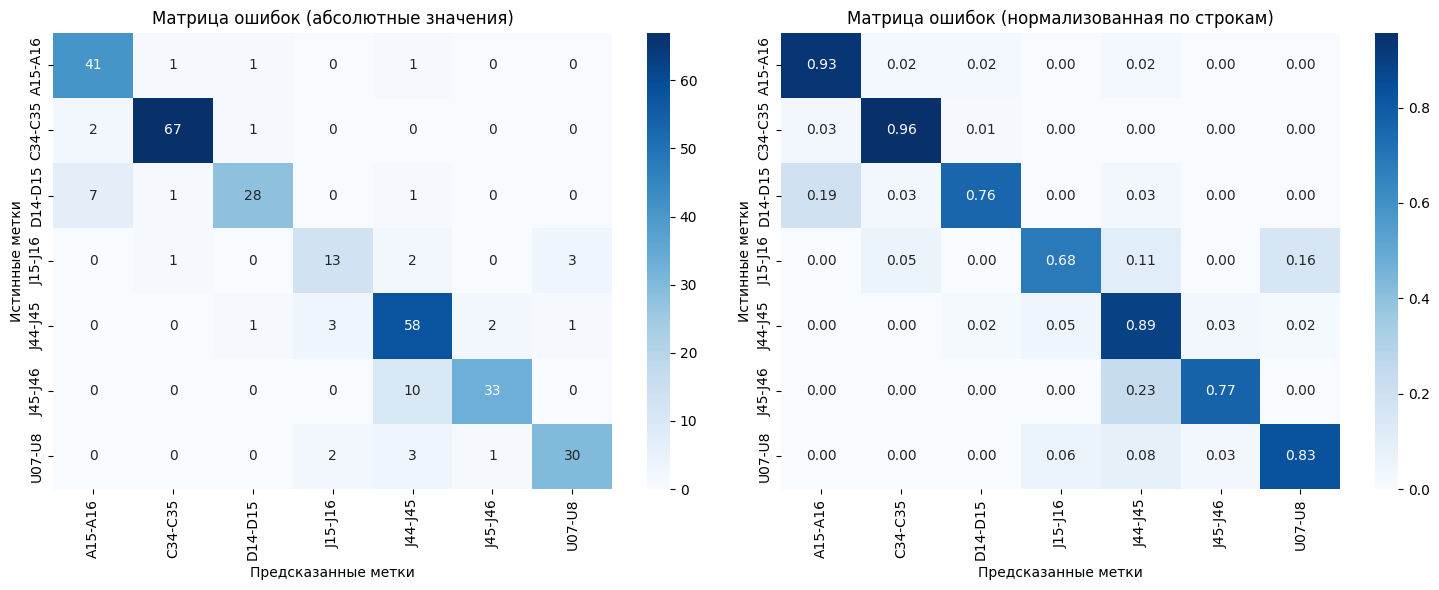


АНАЛИЗ МАТРИЦЫ ОШИБОК:

Точность по классам:
A15-A16: 93.2% (41/44)
C34-C35: 95.7% (67/70)
D14-D15: 75.7% (28/37)
J15-J16: 68.4% (13/19)
J44-J45: 89.2% (58/65)
J45-J46: 76.7% (33/43)
U07-U8: 83.3% (30/36)

Основные ошибки классификации:
  A15-A16 → C34-C35: 1 случаев (2.3%)
  A15-A16 → D14-D15: 1 случаев (2.3%)
  A15-A16 → J44-J45: 1 случаев (2.3%)
  C34-C35 → A15-A16: 2 случаев (2.9%)
  C34-C35 → D14-D15: 1 случаев (1.4%)
  D14-D15 → A15-A16: 7 случаев (18.9%)
  D14-D15 → C34-C35: 1 случаев (2.7%)
  D14-D15 → J44-J45: 1 случаев (2.7%)
  J15-J16 → C34-C35: 1 случаев (5.3%)
  J15-J16 → J44-J45: 2 случаев (10.5%)
  J15-J16 → U07-U8: 3 случаев (15.8%)
  J44-J45 → D14-D15: 1 случаев (1.5%)
  J44-J45 → J15-J16: 3 случаев (4.6%)
  J44-J45 → J45-J46: 2 случаев (3.1%)
  J44-J45 → U07-U8: 1 случаев (1.5%)
  J45-J46 → J44-J45: 10 случаев (23.3%)
  U07-U8 → J15-J16: 2 случаев (5.6%)
  U07-U8 → J44-J45: 3 случаев (8.3%)
  U07-U8 → J45-J46: 1 случаев (2.8%)


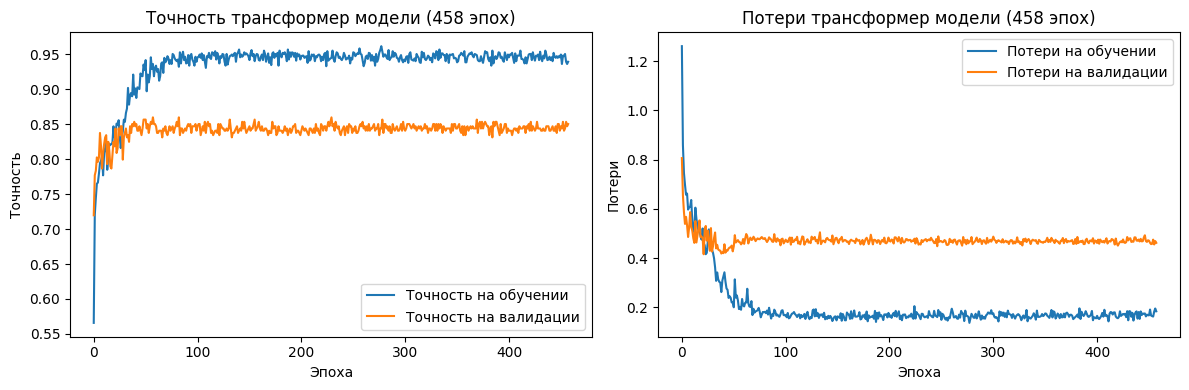

In [18]:

# Матрица ошибок
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=label_encoder.classes_,
           yticklabels=label_encoder.classes_)
plt.title('Матрица ошибок (абсолютные значения)')
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинные метки')

plt.subplot(1, 2, 2)
cm_normalized = confusion_matrix(y_true, y_pred, normalize='true')
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
           xticklabels=label_encoder.classes_,
           yticklabels=label_encoder.classes_)
plt.title('Матрица ошибок (нормализованная по строкам)')
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинные метки')

plt.tight_layout()
plt.show()

# Анализ матрицы ошибок
print("\nАНАЛИЗ МАТРИЦЫ ОШИБОК:")
print("=" * 50)

cm_abs = confusion_matrix(y_true, y_pred)
cm_norm = confusion_matrix(y_true, y_pred, normalize='true')

print("\nТочность по классам:")
for i, class_name in enumerate(label_encoder.classes_):
    accuracy = cm_norm[i, i]
    total = np.sum(cm_abs[i, :])
    correct = cm_abs[i, i]
    print(f"{class_name}: {accuracy:.1%} ({correct}/{total})")

print("\nОсновные ошибки классификации:")
error_found = False
for i in range(len(label_encoder.classes_)):
    for j in range(len(label_encoder.classes_)):
        if i != j and cm_abs[i, j] > 0:
            error_found = True
            true_class = label_encoder.classes_[i]
            pred_class = label_encoder.classes_[j]
            count = cm_abs[i, j]
            percentage = cm_norm[i, j]
            print(f"  {true_class} → {pred_class}: {count} случаев ({percentage:.1%})")

if not error_found:
    print("  Все предсказания верны!")

# Графики обучения
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_accuracies, label='Точность на обучении')
plt.plot(val_accuracies, label='Точность на валидации')
plt.title(f'Точность трансформер модели ({actual_epochs} эпох)')
plt.xlabel('Эпоха')
plt.ylabel('Точность')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Потери на обучении')
plt.plot(val_losses, label='Потери на валидации')
plt.title(f'Потери трансформер модели ({actual_epochs} эпох)')
plt.xlabel('Эпоха')
plt.ylabel('Потери')
plt.legend()

plt.tight_layout()
plt.show()

# БЛОК 10: СОХРАНЕНИЕ МОДЕЛИ И ДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ

In [19]:
# Сохранение модели и preprocessing объектов
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'input_dim': input_dim,
    'num_classes': num_classes,
    'hidden_dim': 256,
    'num_heads': 8
}, 'medical_epicrisis_transformer_model.pth')

joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')
joblib.dump(feature_columns, 'feature_columns.pkl')

print("Трансформер модель и preprocessing objects сохранены!")

# Информация о диагнозах
diagnosis_info = df[['diagnosis_code', 'diagnosis_name']].drop_duplicates()
diagnosis_info = diagnosis_info.sort_values('diagnosis_code').reset_index(drop=True)

print("\nКлассы диагнозов в наборе данных:")
print("=" * 60)

for idx, row in diagnosis_info.iterrows():
    code = row['diagnosis_code']
    name = row['diagnosis_name']
    
    if pd.isna(name) or name == '':
        name = "Название не указано"
    
    print(f"{code}: {name}")

print("=" * 60)
print(f"Всего классов: {len(diagnosis_info)}")

# Статистика по классам
print("\nСтатистика по классам:")
print("-" * 40)

diagnosis_counts = df['diagnosis_code'].value_counts()
for code, count in diagnosis_counts.items():
    name = diagnosis_info[diagnosis_info['diagnosis_code'] == code]['diagnosis_name'].iloc[0]
    if pd.isna(name) or name == '': 
        name = "Название не указано"
    percentage = (count / len(df)) * 100
    print(f"{code}: {count} записей ({percentage:.1f}%) - {name}")

Трансформер модель и preprocessing objects сохранены!

Классы диагнозов в наборе данных:
A15-A16: Туберкулез легких (объединенный класс)
C34-C35: Злокачественное новообразование легкого (объединенный класс)
D14-D15: Заболевание класса D14 (объединенный класс)
J15-J16: Бактериальная пневмония (объединенный класс)
J44-J45: Другая хроническая обструктивная легочная болезнь (объединенный класс)
J45-J46: Астма (объединенный класс)
U07-U8: COVID-19 (объединенный класс)
Всего классов: 7

Статистика по классам:
----------------------------------------
C34-C35: 350 записей (22.3%) - Злокачественное новообразование легкого (объединенный класс)
J44-J45: 324 записей (20.7%) - Другая хроническая обструктивная легочная болезнь (объединенный класс)
A15-A16: 221 записей (14.1%) - Туберкулез легких (объединенный класс)
J45-J46: 214 записей (13.6%) - Астма (объединенный класс)
D14-D15: 185 записей (11.8%) - Заболевание класса D14 (объединенный класс)
U07-U8: 180 записей (11.5%) - COVID-19 (объединенный 

# БЛОК 11: ФУНКЦИЯ ДЛЯ ПРЕДСКАЗАНИЙ

In [20]:

def predict_diagnosis(model, features, scaler, label_encoder, device):
    """
    Функция для предсказания диагноза на новых данных
    """
    model.eval()
    
    # Преобразование и нормализация признаков
    features_scaled = scaler.transform([features])
    features_tensor = torch.FloatTensor(features_scaled).to(device)
    
    with torch.no_grad():
        outputs = model(features_tensor)
        probabilities = torch.softmax(outputs, dim=1)
        predicted_class = torch.argmax(outputs, dim=1)
        confidence = torch.max(probabilities, dim=1)[0]
    
    diagnosis_code = label_encoder.inverse_transform([predicted_class.cpu().item()])[0]
    confidence_score = confidence.cpu().item()
    
    return diagnosis_code, confidence_score

print("\n✅ Модель готова к использованию!")


✅ Модель готова к использованию!
